# 🦄 Panoptic Long Straddle — Бэктест на Uniswap V3

## Ячейка 1 — Установка

In [1]:
!pip install fractal-defi pandas numpy matplotlib seaborn -q

## Ячейка 2 — Импорты

In [2]:
import warnings
warnings.filterwarnings('ignore')

from collections import deque
from dataclasses import dataclass
from datetime import UTC, datetime
from itertools import product
from typing import Deque, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from fractal.core.base import (
    Action, ActionToTake, BaseStrategy,
    BaseStrategyParams, NamedEntity, Observation,
)
from fractal.core.base.entity import BaseEntity, EntityException, GlobalState, InternalState
from fractal.core.entities.models.uniswap_v3_fees import estimate_fee, get_liquidity_delta
from fractal.core.entities.protocols.uniswap_v3_lp import (
    UniswapV3LPConfig, UniswapV3LPEntity, UniswapV3LPGlobalState,
)
from fractal.loaders.base_loader import LoaderType
from fractal.loaders.thegraph.uniswap_v3.uniswap_v3_pool import (
    UniswapV3EthereumPoolHourDataLoader,
)
from fractal.loaders.thegraph.uniswap_v3.uniswap_v3_spot_prices import (
    UniswapV3EthereumPricesLoader,
)

print('✅ Импорты успешны')

✅ Импорты успешны


## Ячейка 3 — Конфигурация

In [3]:
API_KEY = '99627e66ef9772295ae3fb9f5ed65c7a'   # https://thegraph.com/studio/apikeys/

# ETH/USDC 0.3% пул на Ethereum mainnet
ETH_USDC_POOL = '0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8'

START_DATE = datetime(2022, 1, 1, tzinfo=UTC)
END_DATE   = datetime(2024, 1, 1, tzinfo=UTC)

INITIAL_BALANCE = 10_000.0   # USDC

print(f'📅 Период: {START_DATE.date()} → {END_DATE.date()}')
print(f'💵 Начальный баланс: ${INITIAL_BALANCE:,.0f}')
print(f'🏊 Пул: {ETH_USDC_POOL}')

📅 Период: 2022-01-01 → 2024-01-01
💵 Начальный баланс: $10,000
🏊 Пул: 0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8


## Ячейка 4 — States

In [4]:
@dataclass
class PoolGlobalState(GlobalState):
    """Состояние пула Uniswap V3 на одном баре.

    iv_annual передаётся напрямую (предрассчитан в load_pool_data
    как скользящая реализованная волатильность за 168 ч).
    """
    price: float = 0.0
    fees: float = 0.0
    liquidity: float = 0.0
    volume: float = 0.0
    tvl: float = 0.0
    iv_annual: float = 0.0   # ← предрассчитанная годовая волатильность

    @property
    def implied_volatility(self) -> float:
        """Возвращаем предрассчитанную годовую волатильность."""
        return self.iv_annual


@dataclass
class StraddleInternalState(InternalState):
    """Внутреннее состояние Long Straddle позиции."""
    is_open: bool = False
    entry_price: float = 0.0
    notional: float = 0.0
    collateral: float = 0.0
    accumulated_premium: float = 0.0
    bars_held: int = 0
    cash: float = 0.0

print('✅ States обновлены')

✅ States обновлены


## Ячейка 5 — Entity

In [6]:
# ══════════════════════════════════════════
#  PANOPTIC STRADDLE ENTITY
# ══════════════════════════════════════════

class PanopticStraddleEntity(BaseEntity):
    """
    Long Straddle в Panoptic поверх Uniswap V3.

    Механика потоковой премии (Panoptic whitepaper §III.A):
        Premium = ∫ θ(S_t, K, σ) dt

    В дискретном виде за каждый бар:
        premium_bar = estimate_fee(our_L, pool_L, pool_fees_bar)

    PnL покупателя:
        intrinsic = |current_price - entry_price|
        pnl       = intrinsic - accumulated_premium
    """

    TOKEN0_DECIMALS: int = 18    # ETH
    TOKEN1_DECIMALS: int = 6     # USDC
    POOL_FEE_RATE: float = 0.003
    TICK_SPACING_PCT: float = 0.006   # ~0.6% для 0.3% пула

    def _initialize_states(self) -> None:
        self._global_state = PoolGlobalState()
        self._internal_state = StraddleInternalState()

    def update_state(self, state: PoolGlobalState) -> None:
        """Вызывается ДО predict. Начисляем streaming premium."""
        self._global_state = state
        if not self._internal_state.is_open:
            return
        self._internal_state.accumulated_premium += (
            self._calculate_streaming_premium(state)
        )
        self._internal_state.bars_held += 1

    def _calculate_streaming_premium(self, state: PoolGlobalState) -> float:
        """Потоковая премия за один бар через V3 математику."""
        if state.liquidity <= 0 or state.fees <= 0:
            return 0.0
        our_L = self._estimate_our_liquidity(state)
        if our_L <= 0:
            return 0.0
        return estimate_fee(
            liquidity_delta=int(our_L),
            liquidity=int(state.liquidity),
            fees=state.fees,
        )

    def _estimate_our_liquidity(self, state: PoolGlobalState) -> float:
        """Оценка нашей L для стрэддла (пут + колл нога)."""
        if state.price <= 0:
            return 0.0

        entry = self._internal_state.entry_price
        half  = self._internal_state.notional / 2

        # Пут: ликвидность в диапазоне [K*(1-δ), K]
        put_lower  = entry * (1 - self.TICK_SPACING_PCT)
        put_upper  = entry
        # Колл: ликвидность в диапазоне [K, K*(1+δ)]
        call_lower = entry
        call_upper = entry * (1 + self.TICK_SPACING_PCT)

        try:
            L_put = get_liquidity_delta(
                P=state.price,
                lower_price=put_lower,
                upper_price=put_upper,
                amount0=0.0,
                amount1=half,
                token0_decimal=self.TOKEN0_DECIMALS,
                token1_decimal=self.TOKEN1_DECIMALS,
            )
            L_call = get_liquidity_delta(
                P=state.price,
                lower_price=call_lower,
                upper_price=call_upper,
                amount0=half / state.price,
                amount1=0.0,
                token0_decimal=self.TOKEN0_DECIMALS,
                token1_decimal=self.TOKEN1_DECIMALS,
            )
            return float(L_put + L_call)
        except (ValueError, ZeroDivisionError):
            # Fallback: грубая оценка через нотионал
            return (self._internal_state.notional / state.price ** 0.5) * 1e9

    # ── Производные свойства ─────────────────────────────────────────────

    @property
    def intrinsic_value(self) -> float:
        """Intrinsic value стрэддла = |S_t - K|."""
        if not self._internal_state.is_open:
            return 0.0
        return abs(self._global_state.price - self._internal_state.entry_price)

    @property
    def unrealized_pnl(self) -> float:
        """PnL = intrinsic - accumulated_premium."""
        return self.intrinsic_value - self._internal_state.accumulated_premium

    @property
    def balance(self) -> float:
        """Полный баланс: кэш + залог + нереализованный PnL."""
        return (
            self._internal_state.cash
            + self._internal_state.collateral
            + self.unrealized_pnl
        )

    # ── Actions ──────────────────────────────────────────────────────────

    def action_deposit(self, amount_in_notional: float) -> None:
        if amount_in_notional < 0:
            raise EntityException(f'deposit < 0: {amount_in_notional}')
        self._internal_state.cash += amount_in_notional

    def action_withdraw(self, amount_in_notional: float) -> None:
        if amount_in_notional > self._internal_state.cash:
            raise EntityException('Недостаточно кэша')
        self._internal_state.cash -= amount_in_notional

    def action_open(
        self,
        notional: float,
        collateral: float,
        commission: float,
        gas_usd: float,
    ) -> None:
        if self._internal_state.is_open:
            raise EntityException('Позиция уже открыта')
        total_cost = collateral + commission + gas_usd
        if self._internal_state.cash < total_cost:
            raise EntityException(
                f'Недостаточно средств: нужно {total_cost:.2f}, '
                f'есть {self._internal_state.cash:.2f}'
            )
        self._internal_state.cash -= total_cost
        self._internal_state.is_open = True
        self._internal_state.entry_price = self._global_state.price
        self._internal_state.notional = notional
        self._internal_state.collateral = collateral
        self._internal_state.accumulated_premium = commission + gas_usd
        self._internal_state.bars_held = 0

    def action_close(self, commission: float, gas_usd: float) -> None:
        if not self._internal_state.is_open:
            raise EntityException('Нет открытой позиции')
        realized_pnl = self.unrealized_pnl - commission - gas_usd
        self._internal_state.cash += (
            self._internal_state.collateral + realized_pnl
        )
        self._internal_state.is_open = False
        self._internal_state.entry_price = 0.0
        self._internal_state.notional = 0.0
        self._internal_state.collateral = 0.0
        self._internal_state.accumulated_premium = 0.0
        self._internal_state.bars_held = 0

print('✅ PanopticStraddleEntity определён')

✅ PanopticStraddleEntity определён


## Ячейка 6 — Strategy

In [7]:
# ══════════════════════════════════════════
#  STRATEGY
# ══════════════════════════════════════════

@dataclass
class StraddleParams(BaseStrategyParams):
    INITIAL_BALANCE: float = 10_000.0

    # 1. КАПИТАЛ
    # Номинал = 80% депо ($8000), залог покупателя = 10% от номинала = $800.
    # Так комиссии за газ не съедают прибыль на маленьких позициях.
    NOTIONAL_FRACTION: float = 0.80
    COLLATERAL_PCT: float = 0.10      # залог = 10% от notional
    LP_RANGE_PCT: float = 0.10        # ±10% диапазон LP бейзлайна

    # 2. ВХОД: ждём низкой волатильности
    IV_ENTRY_PERCENTILE: float = 80.0         # входим в нижних 30% IV
    VOLUME_ENTRY_PERCENTILE: float = 100.0    # объём не фильтруем
    LOOKBACK_BARS: int = 14 * 24              # 14 дней памяти

    # 3. ВЫХОД
    # TP: intrinsic >= TAKE_PROFIT_MULT * (premium + комиссии + газ * 2)
    TAKE_PROFIT_MULT: float = 1.5
    # SL по бюджету: суммарные затраты > X% от депозита
    STOP_LOSS_BUDGET_PCT: float = 0.05
    # Дейли-стрэддл: держим ровно 24 часа
    MAX_HOLD_BARS: int = 1 * 24

    # 4. ИЗДЕРЖКИ (нули для чистого тестирования механики)
    PANOPTIC_COMMISSION_PCT: float = 0.001
    GAS_USD: float = 2.0


class PanopticStraddleStrategy(BaseStrategy):
    """Long Straddle на Panoptic + пассивный LP бейзлайн."""

    PARAMS_CLS = StraddleParams

    def set_up(self) -> None:
        self.register_entity(NamedEntity(
            entity_name='STRADDLE',
            entity=PanopticStraddleEntity(),
        ))
        self.register_entity(NamedEntity(
            entity_name='LP',
            entity=UniswapV3LPEntity(config=UniswapV3LPConfig(
                pool_fee_rate=0.003,
                slippage_pct=0.001,
                token0_decimals=18,
                token1_decimals=6,
                notional_side='token1',
            )),
        ))
        self._iv_history: Deque[float] = deque(maxlen=self._params.LOOKBACK_BARS)
        self._initialized: bool = False

    def predict(self) -> List[ActionToTake]:
        straddle: PanopticStraddleEntity = self.get_entity('STRADDLE')
        state: PoolGlobalState = straddle.global_state

        # ── Первый бар: вносим депозиты и открываем LP ────────────────────
        if not self._initialized:
            self._initialized = True
            half = self._params.INITIAL_BALANCE / 2
            lp_lower = state.price * (1 - self._params.LP_RANGE_PCT)
            lp_upper = state.price * (1 + self._params.LP_RANGE_PCT)
            return [
                ActionToTake('STRADDLE', Action('deposit',
                    {'amount_in_notional': half})),
                ActionToTake('LP', Action('deposit',
                    {'amount_in_notional': half})),
                ActionToTake('LP', Action('open_position', {
                    'amount_in_notional': half,
                    'price_lower': lp_lower,
                    'price_upper': lp_upper,
                })),
            ]

        # ── Накапливаем историю IV ────────────────────────────────────────
        self._iv_history.append(state.implied_volatility)

        if len(self._iv_history) < self._params.LOOKBACK_BARS:
            return []   # мало данных — ждём

        # ── Торговая логика ───────────────────────────────────────────────
        if not straddle.internal_state.is_open:
            if self._should_enter(state, straddle):
                return self._open_straddle(straddle)
        else:
            return self._check_exit(straddle)

        return []

    # ── Вспомогательные методы ────────────────────────────────────────────

    def _should_enter(self, state: PoolGlobalState, straddle: PanopticStraddleEntity) -> bool:
        """Входим когда IV ниже N-го перцентиля и хватает денег на залог."""
        iv_arr = np.array(self._iv_history)
        iv_threshold = np.percentile(iv_arr, self._params.IV_ENTRY_PERCENTILE)
        iv_ok = state.implied_volatility < iv_threshold

        # Минимально необходимый кэш = залог
        notional = straddle.internal_state.cash * self._params.NOTIONAL_FRACTION
        min_cost = notional * self._params.COLLATERAL_PCT
        balance_ok = straddle.internal_state.cash >= min_cost

        return iv_ok and balance_ok

    def _open_straddle(self, straddle: PanopticStraddleEntity) -> List[ActionToTake]:
        notional   = straddle.internal_state.cash * self._params.NOTIONAL_FRACTION
        collateral = notional * self._params.COLLATERAL_PCT
        commission = notional * self._params.PANOPTIC_COMMISSION_PCT
        return [ActionToTake('STRADDLE', Action('open', {
            'notional':   notional,
            'collateral': collateral,
            'commission': commission,
            'gas_usd':    self._params.GAS_USD,
        }))]

    def _check_exit(self, straddle: PanopticStraddleEntity) -> List[ActionToTake]:
        internal  = straddle.internal_state
        intrinsic = straddle.intrinsic_value
        premium   = internal.accumulated_premium

        # Суммарные издержки: потоковая премия + комиссии при закрытии + газ × 2
        commission_close = internal.notional * self._params.PANOPTIC_COMMISSION_PCT
        gas_close = self._params.GAS_USD
        total_costs = premium + commission_close + gas_close

        reason = None

        # Take Profit: движение цены перекрыло все издержки с множителем
        if total_costs > 0 and intrinsic >= self._params.TAKE_PROFIT_MULT * total_costs:
            reason = 'TAKE_PROFIT'

        # Stop Loss по бюджету: затраты съели X% от депозита
        elif total_costs >= self._params.INITIAL_BALANCE * self._params.STOP_LOSS_BUDGET_PCT:
            reason = 'STOP_LOSS_BUDGET'

        # Time Stop: дейли-стрэддл истёк
        elif internal.bars_held >= self._params.MAX_HOLD_BARS:
            reason = 'TIME_STOP'

        if reason:
            return [ActionToTake('STRADDLE', Action('close', {
                'commission': commission_close,
                'gas_usd':    gas_close,
            }))]
        return []

print('✅ Strategy определена')

✅ Strategy определена


## Ячейка 7 — Загрузка данных

In [8]:
# ══════════════════════════════════════════
#  ЗАГРУЗКА ДАННЫХ
# ══════════════════════════════════════════

def load_pool_data(
    api_key: str,
    pool_address: str,
    start_time: datetime,
    end_time: datetime,
) -> pd.DataFrame:
    """Загружает данные пула + цены из The Graph.

    Пул 0x8ad599 (ETH/USDC 0.3%): token0=USDC(6), token1=WETH(18)
    Тик кодирует price_raw = WETH_raw/USDC_raw (ETH per USDC direction)
    Лоадер: price = 1.0001^tick * 10^decimals
    С decimals = 6-18 = -12 → price ≈ 0.000333 (ETH per USDC)
    Инверсия: 1/price = 3000 (USDC per ETH) ← нужный нам формат
    - IV = скользящая реализованная волатильность за 168 ч (7 дней)
    - PoolHistory и PriceHistory это DataFrame c DatetimeIndex 'time'
    """

    # ── 1. Данные пула ────────────────────────────────────────────────────
    print('  📊 Загружаем данные пула (fees, liquidity, volume)...')
    pool_loader = UniswapV3EthereumPoolHourDataLoader(
        api_key=api_key,
        pool=pool_address,
        loader_type=LoaderType.CSV,
        start_time=start_time,
        end_time=end_time,
    )
    # PoolHistory — это DataFrame с индексом 'time'
    df_pool = pool_loader.read(with_run=True).reset_index()
    # После reset_index: columns = ['time', 'tvl', 'volume', 'fees', 'liquidity']
    df_pool = df_pool.rename(columns={'time': 'timestamp'})

    # ── 2. Цены из тиков ─────────────────────────────────────────────────
    print('  💰 Загружаем цены из тиков...')
    price_loader = UniswapV3EthereumPricesLoader(
        api_key=api_key,
        pool=pool_address,
        loader_type=LoaderType.CSV,
        start_time=start_time,
        end_time=end_time,
        # Пул token0=USDC(6), token1=WETH(18)
        # decimals = dec0 - dec1 = 6 - 18 = -12
        # → price_loader = 1.0001^tick * 1e-12 ≈ 0.000333 (ETH per USDC)
        # Инверсия ниже даёт правильный USDC per ETH ≈ 3000
        decimals=6 - 18,
    )
    # PriceHistory — тоже DataFrame с индексом 'time'
    df_prices = price_loader.read(with_run=True).reset_index()
    # После reset_index: columns = ['time', 'price']
    df_prices = df_prices.rename(columns={'time': 'timestamp'})
    # Инвертируем: лоадер даёт ETH/USDC (≈0.000333), нам нужно USDC/ETH (≈3000)
    df_prices['price'] = 1.0 / df_prices['price']

    # ── 3. Объединяем по времени ──────────────────────────────────────────
    df = pd.merge_asof(
        df_pool.sort_values('timestamp'),
        df_prices.sort_values('timestamp'),
        on='timestamp',
        direction='nearest',
        tolerance=pd.Timedelta('2h'),
    )

    # ── 4. Чистка ─────────────────────────────────────────────────────────
    df = df.dropna(subset=['price', 'fees', 'liquidity'])
    df = df[(df['price'] > 0) & (df['liquidity'] > 0)]
    df = df.sort_values('timestamp').reset_index(drop=True)

    # ── 5. Расчёт IV ──────────────────────────────────────────────────────
    print('  📈 Рассчитываем реализованную волатильность...')
    # Логарифмические часовые доходности
    df['returns'] = np.log(df['price'] / df['price'].shift(1))
    # Скользящая часовая std за 168 ч (7 дней) → годовая волатильность
    # sqrt(24 * 365) = sqrt(8760) ≈ 93.6
    df['iv_annual'] = df['returns'].rolling(window=168).std() * np.sqrt(8760)
    # Заполняем начальные NaN средним по всему ряду
    mean_iv = df['iv_annual'].mean(skipna=True)
    df['iv_annual'] = df['iv_annual'].fillna(mean_iv)
    df['iv'] = df['iv_annual'] / np.sqrt(8760)   # часовая vol (для совместимости)

    return df


def build_observations(df: pd.DataFrame) -> List[Observation]:
    """Строим Observation для каждого бара.

    ВАЖНО: iv_annual теперь передаётся в PoolGlobalState напрямую.
    """
    observations = []
    for _, row in df.iterrows():
        ts = row['timestamp']
        # Гарантируем timezone-aware timestamp
        if hasattr(ts, 'tzinfo') and ts.tzinfo is None:
            ts = ts.replace(tzinfo=UTC)

        observations.append(Observation(
            timestamp=ts,
            states={
                'STRADDLE': PoolGlobalState(
                    price=float(row['price']),
                    fees=float(row['fees']),
                    liquidity=float(row['liquidity']),
                    volume=float(row['volume']),
                    tvl=float(row['tvl']),
                    iv_annual=float(row['iv_annual']),   # ← передаём предрассчитанный IV
                ),
                'LP': UniswapV3LPGlobalState(
                    price=float(row['price']),
                    fees=float(row['fees']),
                    liquidity=float(row['liquidity']),
                    volume=float(row['volume']),
                    tvl=float(row['tvl']),
                ),
            }
        ))
    return observations


# ── Запуск ────────────────────────────────────────────────────────────────
print('📥 Загружаем данные из The Graph...')
df_pool = load_pool_data(API_KEY, ETH_USDC_POOL, START_DATE, END_DATE)
df_pool.to_csv('pool_data.csv', index=False)

print(f'\n✅ Загружено {len(df_pool)} баров')
print(f'   Период:       {df_pool["timestamp"].min()} → {df_pool["timestamp"].max()}')
print(f'   Цена ETH:     ${df_pool["price"].min():.0f} — ${df_pool["price"].max():.0f}')
print(f'   Средний IV:   {df_pool["iv_annual"].mean():.1%} годовых')
df_pool.head()

📥 Загружаем данные из The Graph...
  📊 Загружаем данные пула (fees, liquidity, volume)...
  💰 Загружаем цены из тиков...
  📈 Рассчитываем реализованную волатильность...

✅ Загружено 17497 баров
   Период:       2022-01-01 00:00:00+00:00 → 2023-12-31 00:00:00+00:00
   Цена ETH:     $899 — $3881
   Средний IV:   60.6% годовых


,timestamp,tvl,volume,fees,liquidity,price,returns,iv_annual,iv
0,2022-01-01 00:00:00+00:00,4.055339e+08,1.904408e+06,5713.225283,9.716610e+18,3685.981194,NaN,0.606477,0.00648
1,2022-01-01 01:00:00+00:00,4.055339e+08,1.904408e+06,5713.225283,9.716610e+18,3718.931189,0.0089,0.606477,0.00648
2,2022-01-01 02:00:00+00:00,4.055339e+08,1.904408e+06,5713.225283,9.716610e+18,3734.956221,0.0043,0.606477,0.00648
3,2022-01-01 03:00:00+00:00,4.055339e+08,1.904408e+06,5713.225283,9.716610e+18,3731.969600,-0.0008,0.606477,0.00648
4,2022-01-01 04:00:00+00:00,4.055339e+08,1.904408e+06,5713.225283,9.716610e+18,3731.969600,0.0000,0.606477,0.00648


## Ячейка 8 — Визуализация данных пула

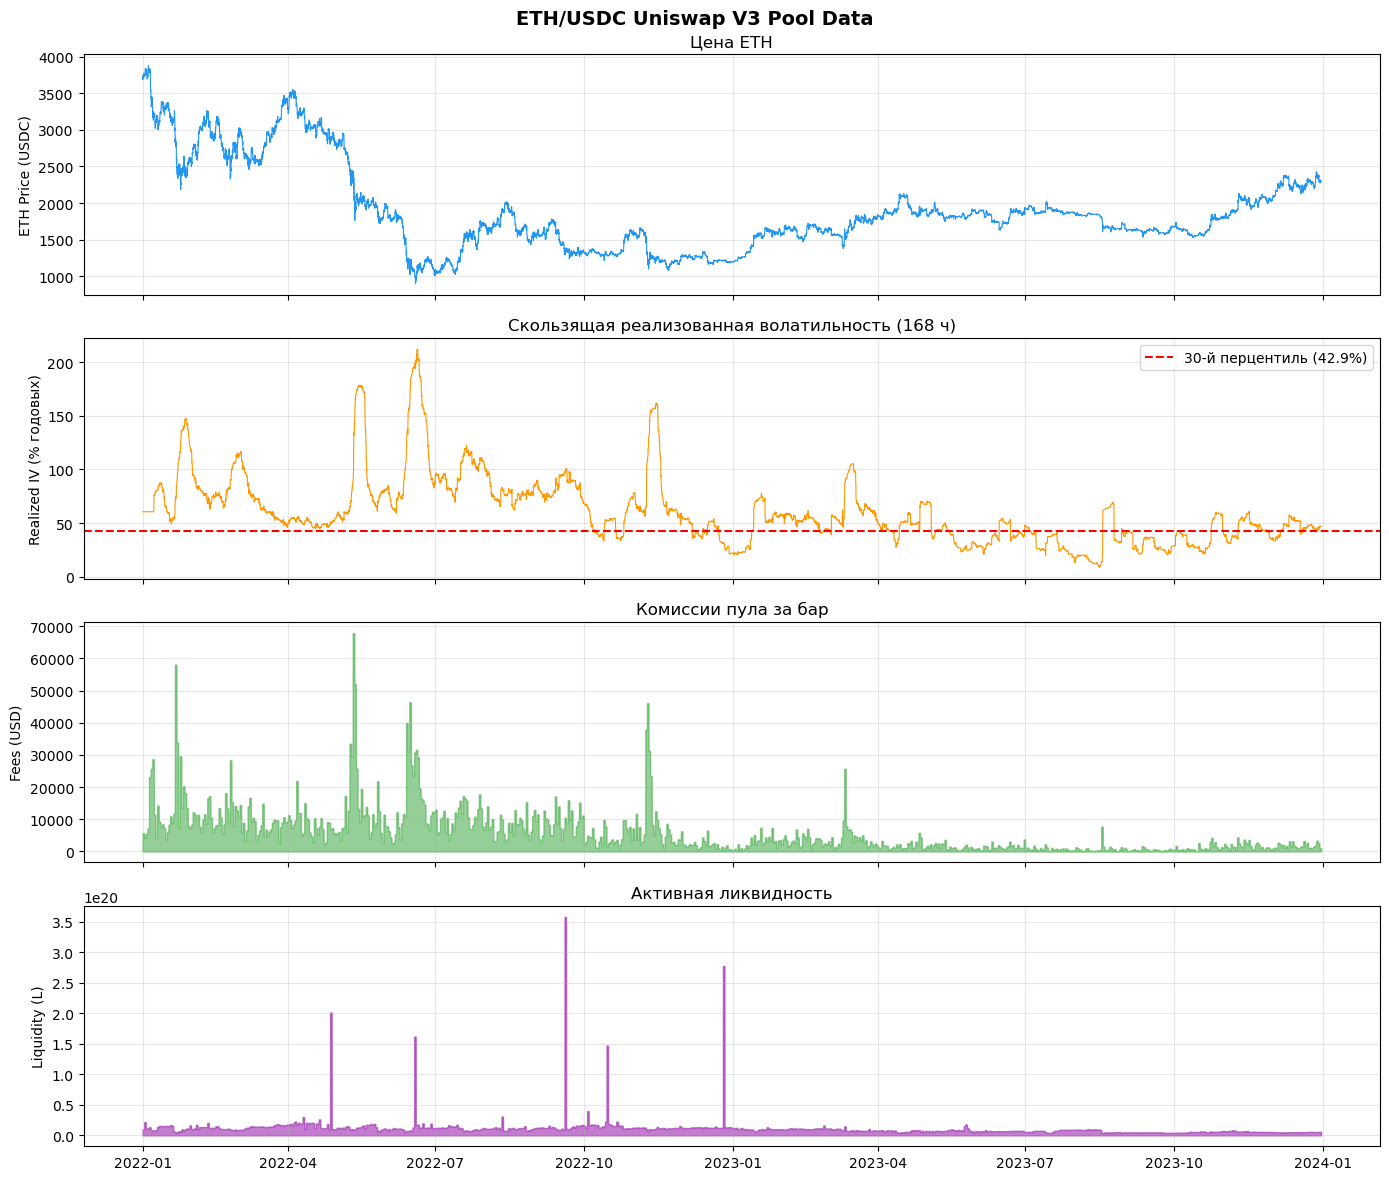

✅ График сохранён: pool_data.png


In [9]:
# ══════════════════════════════════════════
#  ВИЗУАЛИЗАЦИЯ ДАННЫХ ПУЛА
# ══════════════════════════════════════════

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('ETH/USDC Uniswap V3 Pool Data', fontsize=14, fontweight='bold')

# Цена
axes[0].plot(df_pool['timestamp'], df_pool['price'], color='#2196F3', linewidth=0.8)
axes[0].set_ylabel('ETH Price (USDC)')
axes[0].set_title('Цена ETH')
axes[0].grid(alpha=0.3)

# IV (реализованная скользящая)
iv_pct = df_pool['iv_annual'] * 100
axes[1].plot(df_pool['timestamp'], iv_pct, color='#FF9800', linewidth=0.8)
iv_thresh = np.percentile(iv_pct.dropna(), 30)
axes[1].axhline(iv_thresh, color='red', linestyle='--', linewidth=1.5,
                label=f'30-й перцентиль ({iv_thresh:.1f}%)')
axes[1].set_ylabel('Realized IV (% годовых)')
axes[1].set_title('Скользящая реализованная волатильность (168 ч)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Fees
axes[2].fill_between(df_pool['timestamp'], df_pool['fees'], alpha=0.6, color='#4CAF50')
axes[2].set_ylabel('Fees (USD)')
axes[2].set_title('Комиссии пула за бар')
axes[2].grid(alpha=0.3)

# Liquidity
axes[3].fill_between(df_pool['timestamp'], df_pool['liquidity'], alpha=0.6, color='#9C27B0')
axes[3].set_ylabel('Liquidity (L)')
axes[3].set_title('Активная ликвидность')
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pool_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ График сохранён: pool_data.png')

## Ячейка 9 — Одиночный прогон

In [10]:
# ══════════════════════════════════════════
#  ОДИНОЧНЫЙ ПРОГОН
# ══════════════════════════════════════════

print('🚀 Строим observations...')
observations = build_observations(df_pool)
print(f'✅ {len(observations)} observations готовы')

print('\n🎯 Запускаем стратегию...')
params = StraddleParams(INITIAL_BALANCE=INITIAL_BALANCE)
strategy = PanopticStraddleStrategy(params=params, debug=False)
result = strategy.run(observations)

df_result = result.to_dataframe()
metrics   = result.get_default_metrics()

# Метрики LP бейзлайна
lp_entity: UniswapV3LPEntity = strategy.get_entity('LP')
lp_start  = df_result['LP_balance'].iloc[0]
lp_end    = df_result['LP_balance'].iloc[-1]
lp_return = lp_end / lp_start - 1 if lp_start > 0 else 0.0

# Добавляем вспомогательные колонки
df_result['price']     = df_pool['price'].values[:len(df_result)]
df_result['iv_annual'] = df_pool['iv_annual'].values[:len(df_result)]
df_result.to_csv('backtest_result.csv', index=False)

print(f"\n{'='*50}")
print(f'  РЕЗУЛЬТАТЫ БЭКТЕСТА (дефолтные параметры)')
print(f"{'='*50}")
print(f'\n  🎯 STRADDLE STRATEGY:')
print(f'     Sharpe Ratio:   {metrics.sharpe:>8.3f}')
print(f'     APY:            {metrics.apy:>8.2%}')
print(f'     Max Drawdown:   {metrics.max_drawdown:>8.2%}')
print(f'     Total Return:   {metrics.accumulated_return:>8.2%}')
print(f'\n  📈 LP BASELINE:')
print(f'     Total Return:   {lp_return:>8.2%}')
print(f'     Итоговый IL:    ${lp_entity.impermanent_loss:>8.2f}')
print(f"{'='*50}")

🚀 Строим observations...
✅ 17497 observations готовы

🎯 Запускаем стратегию...

  РЕЗУЛЬТАТЫ БЭКТЕСТА (дефолтные параметры)

  🎯 STRADDLE STRATEGY:
     Sharpe Ratio:     -0.530
     APY:             -23.02%
     Max Drawdown:    -75.16%
     Total Return:    -45.98%

  📈 LP BASELINE:
     Total Return:    -30.87%
     Итоговый IL:    $  900.62


## Ячейка 10 — Визуализация результатов

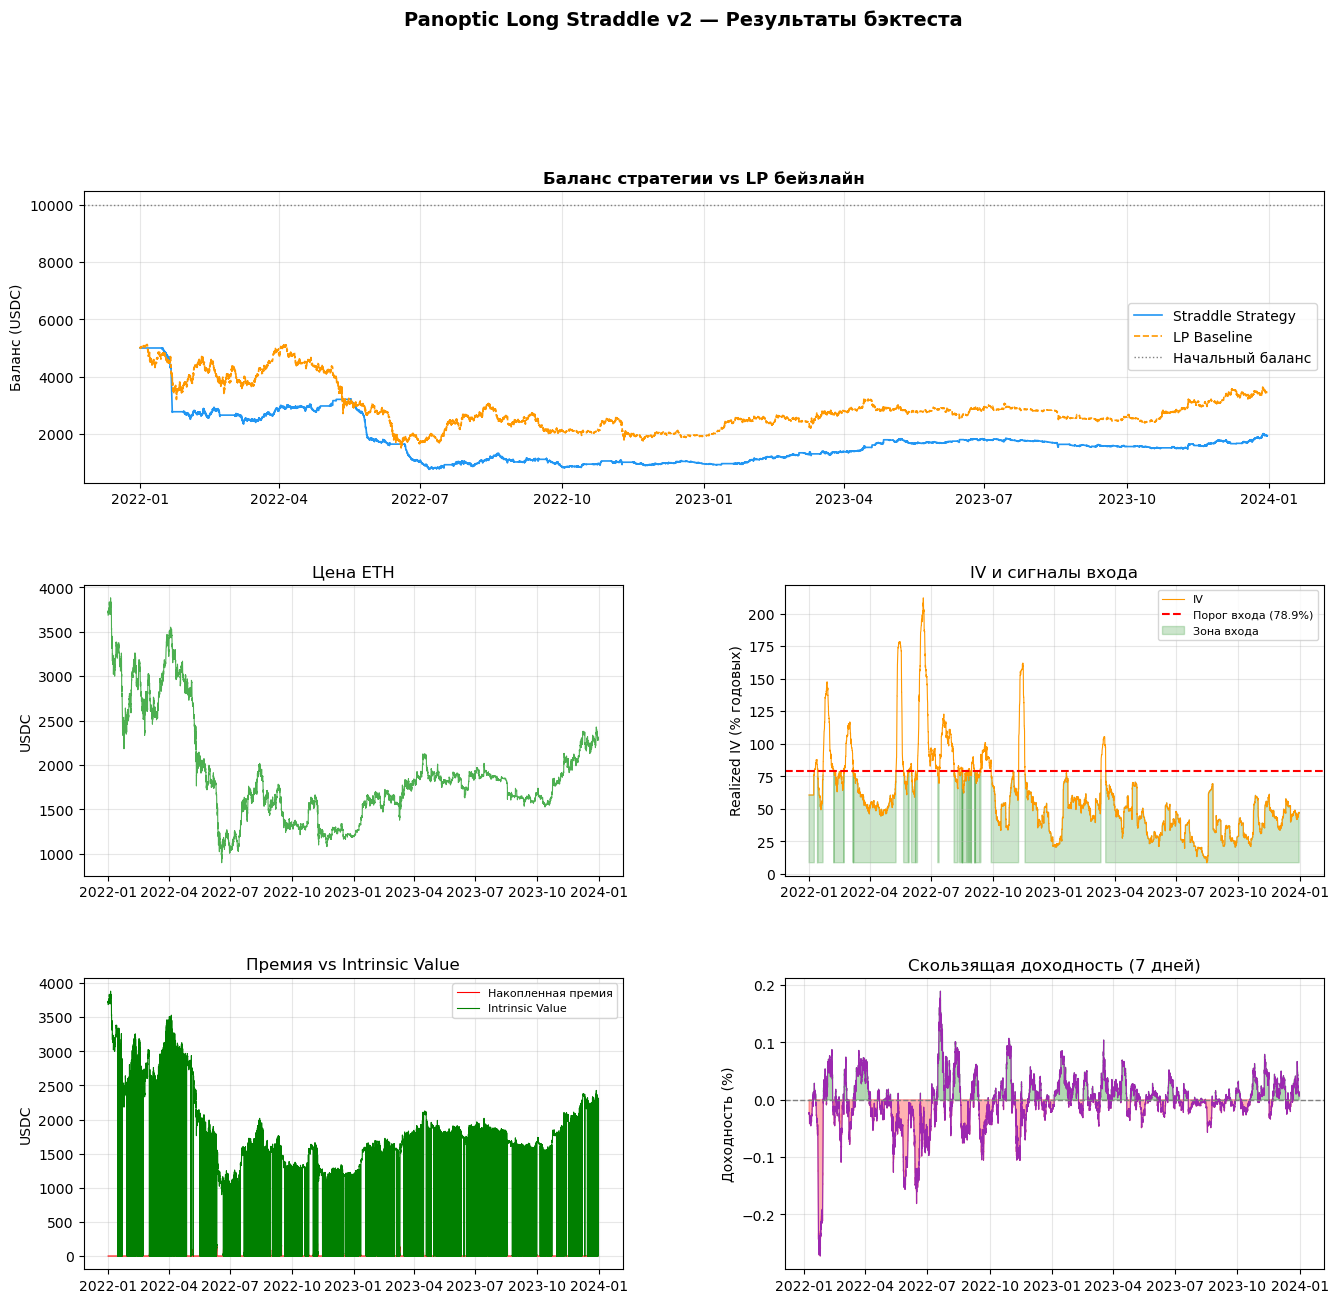

✅ График сохранён: backtest_results.png


In [11]:
# ══════════════════════════════════════════
#  ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ══════════════════════════════════════════

fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

# ── 1. Баланс стрэддла vs LP ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df_result['timestamp'], df_result['STRADDLE_balance'],
         label='Straddle Strategy', color='#2196F3', linewidth=1.2)
ax1.plot(df_result['timestamp'], df_result['LP_balance'],
         label='LP Baseline', color='#FF9800', linewidth=1.2, linestyle='--')
ax1.axhline(INITIAL_BALANCE, color='gray', linestyle=':', linewidth=1,
            label='Начальный баланс')
ax1.set_title('Баланс стратегии vs LP бейзлайн', fontweight='bold')
ax1.set_ylabel('Баланс (USDC)')
ax1.legend()
ax1.grid(alpha=0.3)

# ── 2. Цена ETH ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df_result['timestamp'], df_result['price'], color='#4CAF50', linewidth=0.8)
ax2.set_title('Цена ETH')
ax2.set_ylabel('USDC')
ax2.grid(alpha=0.3)

# ── 3. IV с порогом входа ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
iv_pct_res = df_result['iv_annual'] * 100
ax3.plot(df_result['timestamp'], iv_pct_res, color='#FF9800', linewidth=0.8, label='IV')
iv_thresh_val = np.percentile(iv_pct_res.dropna(), params.IV_ENTRY_PERCENTILE)
ax3.axhline(iv_thresh_val, color='red', linestyle='--', linewidth=1.5,
            label=f'Порог входа ({iv_thresh_val:.1f}%)')
mask = iv_pct_res < iv_thresh_val
ax3.fill_between(df_result['timestamp'], iv_pct_res.min(), iv_pct_res,
                 where=mask, alpha=0.2, color='green', label='Зона входа')
ax3.set_title('IV и сигналы входа')
ax3.set_ylabel('Realized IV (% годовых)')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── 4. Накопленная премия vs Intrinsic ───────────────────
ax4 = fig.add_subplot(gs[2, 0])
if 'STRADDLE_accumulated_premium' in df_result.columns:
    ax4.plot(df_result['timestamp'], df_result['STRADDLE_accumulated_premium'],
             label='Накопленная премия', color='red', linewidth=0.8)
if 'STRADDLE_entry_price' in df_result.columns:
    intrinsic_series = (df_result['price'] - df_result['STRADDLE_entry_price']).abs()
    ax4.plot(df_result['timestamp'], intrinsic_series,
             label='Intrinsic Value', color='green', linewidth=0.8)
ax4.set_title('Премия vs Intrinsic Value')
ax4.set_ylabel('USDC')
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# ── 5. Скользящая доходность (7 дней) ────────────────────
ax5 = fig.add_subplot(gs[2, 1])
net_balance = df_result['net_balance']
rolling_ret = net_balance.pct_change().rolling(24 * 7).mean() * 100
ax5.plot(df_result['timestamp'], rolling_ret, color='#9C27B0', linewidth=0.8)
ax5.axhline(0, color='gray', linestyle='--', linewidth=1)
ax5.fill_between(df_result['timestamp'], rolling_ret, 0,
                 where=(rolling_ret >= 0), alpha=0.3, color='green')
ax5.fill_between(df_result['timestamp'], rolling_ret, 0,
                 where=(rolling_ret < 0), alpha=0.3, color='red')
ax5.set_title('Скользящая доходность (7 дней)')
ax5.set_ylabel('Доходность (%)')
ax5.grid(alpha=0.3)

fig.suptitle('Panoptic Long Straddle v2 — Результаты бэктеста',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ График сохранён: backtest_results.png')

## Ячейка 11 — Grid Search

In [12]:
# ══════════════════════════════════════════
#  GRID SEARCH
# ══════════════════════════════════════════

param_grid = {
    'IV_ENTRY_PERCENTILE':  [30, 40, 50, 60],
    'TAKE_PROFIT_MULT':     [1.2, 1.5, 2.0],
    'STOP_LOSS_BUDGET_PCT': [0.02, 0.05, 0.08],
    'MAX_HOLD_BARS':        [12, 24, 48, 72],
    'NOTIONAL_FRACTION':    [0.50, 0.65, 0.80],
}

keys   = list(param_grid.keys())
values = list(param_grid.values())
combos = list(product(*values))
total  = len(combos)

print(f'🔍 Grid Search: {total} комбинаций...')
print(f'   Параметры: {keys}\n')

results_grid = []
best_sharpe  = -999

from tqdm.auto import tqdm

pbar = tqdm(
    combos,
    total=total,
    desc='Grid Search',
    unit='run',
    bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]',
    dynamic_ncols=True,
)

for combo in pbar:
    p = dict(zip(keys, combo))
    try:
        s = PanopticStraddleStrategy(
            params=StraddleParams(INITIAL_BALANCE=INITIAL_BALANCE, **p)
        )
        r = s.run(observations)
        m = r.get_default_metrics()

        results_grid.append({
            **p,
            'max_hold_hours':    p['MAX_HOLD_BARS'],
            'straddle_sharpe':   m.sharpe,
            'straddle_apy':      m.apy,
            'straddle_drawdown': m.max_drawdown,
            'straddle_return':   m.accumulated_return,
        })

        if m.sharpe > best_sharpe:
            best_sharpe = m.sharpe

    except Exception as e:
        results_grid.append({**p, 'straddle_sharpe': -999, 'error': str(e)})

    pbar.set_postfix({'best_sharpe': f'{best_sharpe:.3f}'}, refresh=False)

pbar.close()

df_grid = pd.DataFrame(results_grid).sort_values('straddle_sharpe', ascending=False)
df_grid.to_csv('grid_search_results.csv', index=False)

print(f'\n✅ Grid Search завершён!')
print(f'\n🏆 ТОП-10 по Sharpe Ratio:')
display_cols = [
    'IV_ENTRY_PERCENTILE', 'TAKE_PROFIT_MULT', 'STOP_LOSS_BUDGET_PCT',
    'max_hold_hours', 'NOTIONAL_FRACTION',
    'straddle_sharpe', 'straddle_apy', 'straddle_drawdown',
]
df_grid.head(10)[display_cols].style.background_gradient(
    subset=['straddle_sharpe'], cmap='RdYlGn'
)

🔍 Grid Search: 432 комбинаций...
   Параметры: ['IV_ENTRY_PERCENTILE', 'TAKE_PROFIT_MULT', 'STOP_LOSS_BUDGET_PCT', 'MAX_HOLD_BARS', 'NOTIONAL_FRACTION']



Grid Search:   0%|                                                                            | 0/432 [00:00<?…


✅ Grid Search завершён!

🏆 ТОП-10 по Sharpe Ratio:


,IV_ENTRY_PERCENTILE,TAKE_PROFIT_MULT,STOP_LOSS_BUDGET_PCT,max_hold_hours,NOTIONAL_FRACTION,straddle_sharpe,straddle_apy,straddle_drawdown
357,60,1.200000,0.080000,72,0.500000,-0.428963,-0.177909,-0.702192
354,60,1.200000,0.080000,48,0.500000,-0.447124,-0.181001,-0.696881
411,60,2.000000,0.050000,24,0.500000,-0.450774,-0.181617,-0.690818
423,60,2.000000,0.080000,24,0.500000,-0.455414,-0.181616,-0.690794
342,60,1.200000,0.050000,48,0.500000,-0.455516,-0.181195,-0.680948
399,60,2.000000,0.020000,24,0.500000,-0.457171,-0.181881,-0.685277
345,60,1.200000,0.050000,72,0.500000,-0.464622,-0.184077,-0.694243
381,60,1.500000,0.050000,72,0.500000,-0.466972,-0.196867,-0.714697
333,60,1.200000,0.020000,72,0.500000,-0.472588,-0.183385,-0.675969
393,60,1.500000,0.080000,72,0.500000,-0.473025,-0.198121,-0.719512


## Ячейка 12 — Визуализация Grid Search

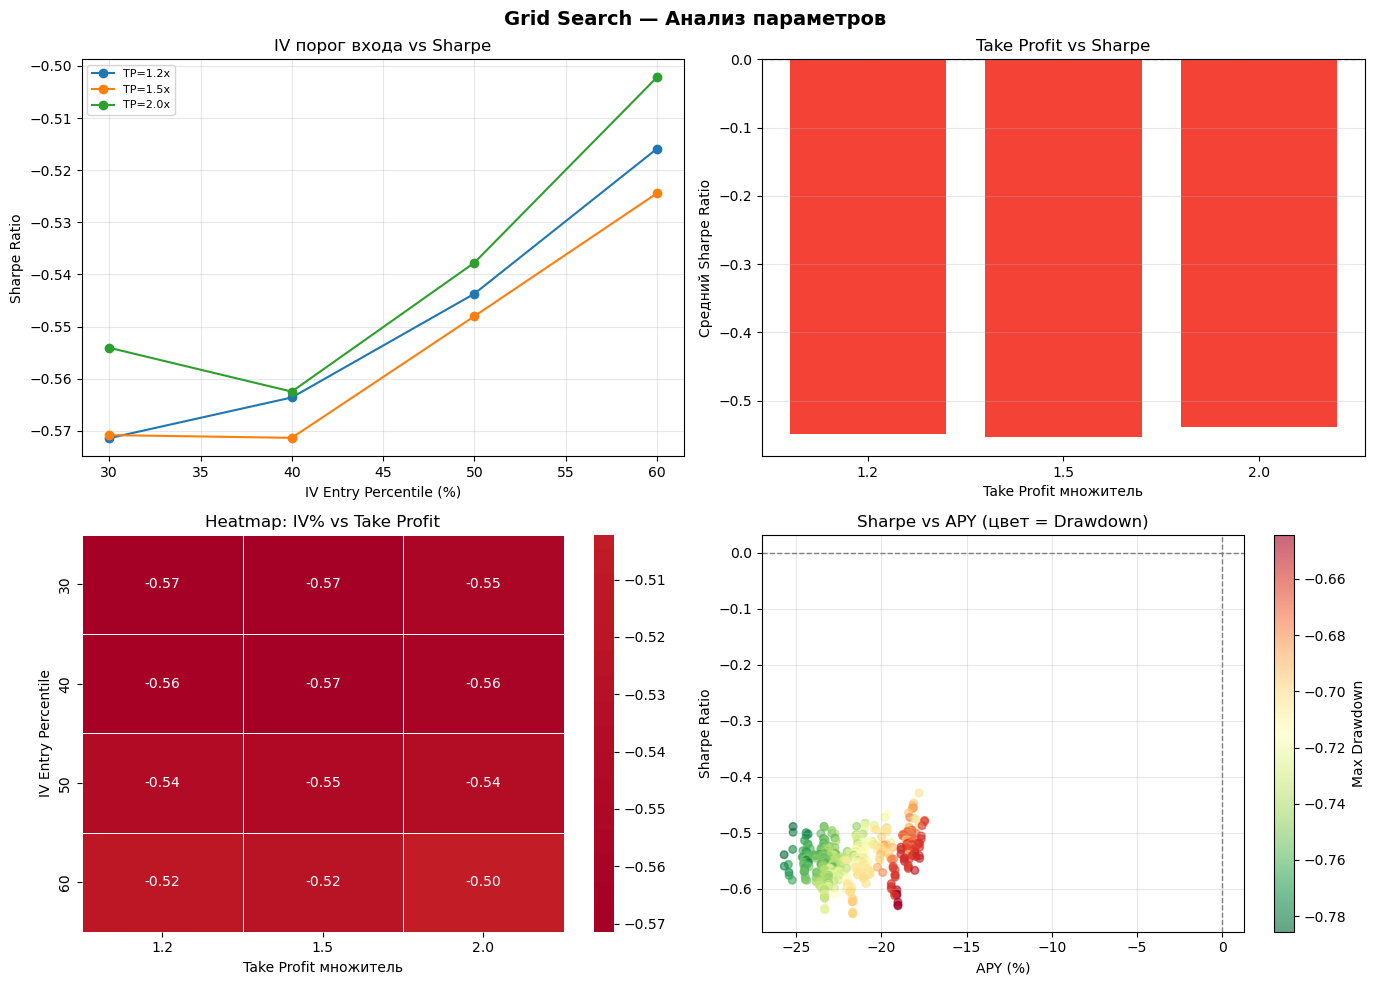

✅ График сохранён: grid_search_analysis.png


In [13]:
# ══════════════════════════════════════════
#  ВИЗУАЛИЗАЦИЯ GRID SEARCH
# ══════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Grid Search — Анализ параметров', fontsize=14, fontweight='bold')

df_valid = df_grid[df_grid['straddle_sharpe'] > -999].copy()

# ── 1. IV перцентиль vs Sharpe ───────────────────────────
ax = axes[0, 0]
for tp in sorted(df_valid['TAKE_PROFIT_MULT'].unique()):
    subset  = df_valid[df_valid['TAKE_PROFIT_MULT'] == tp]
    grouped = subset.groupby('IV_ENTRY_PERCENTILE')['straddle_sharpe'].mean()
    ax.plot(grouped.index, grouped.values, marker='o', label=f'TP={tp}x')
ax.set_xlabel('IV Entry Percentile (%)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('IV порог входа vs Sharpe')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 2. Take Profit vs Sharpe ─────────────────────────────
ax = axes[0, 1]
grouped = df_valid.groupby('TAKE_PROFIT_MULT')['straddle_sharpe'].mean()
colors  = ['#4CAF50' if v > 0 else '#F44336' for v in grouped.values]
ax.bar(grouped.index.astype(str), grouped.values, color=colors)
ax.set_xlabel('Take Profit множитель')
ax.set_ylabel('Средний Sharpe Ratio')
ax.set_title('Take Profit vs Sharpe')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='y')

# ── 3. Heatmap: IV% vs TP ────────────────────────────────
ax = axes[1, 0]
pivot = df_valid.pivot_table(
    values='straddle_sharpe',
    index='IV_ENTRY_PERCENTILE',
    columns='TAKE_PROFIT_MULT',
    aggfunc='mean',
)
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5)
ax.set_title('Heatmap: IV% vs Take Profit')
ax.set_xlabel('Take Profit множитель')
ax.set_ylabel('IV Entry Percentile')

# ── 4. Sharpe vs APY scatter (цвет = Drawdown) ───────────
ax = axes[1, 1]
scatter = ax.scatter(
    df_valid['straddle_apy'] * 100,
    df_valid['straddle_sharpe'],
    c=df_valid['straddle_drawdown'],
    cmap='RdYlGn_r',
    alpha=0.6,
    s=30,
)
plt.colorbar(scatter, ax=ax, label='Max Drawdown')
ax.set_xlabel('APY (%)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe vs APY (цвет = Drawdown)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.axvline(0, color='gray', linestyle='--', linewidth=1)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('grid_search_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ График сохранён: grid_search_analysis.png')

## Ячейка 13 — Финальный прогон с лучшими параметрами

In [14]:
# ══════════════════════════════════════════
#  ФИНАЛЬНЫЙ ПРОГОН С ЛУЧШИМИ ПАРАМЕТРАМИ
# ══════════════════════════════════════════

best_row = df_grid.iloc[0]
print('🏆 Лучшие параметры:')
print(f'   IV Entry Percentile:  {best_row["IV_ENTRY_PERCENTILE"]}%')
print(f'   Take Profit:          {best_row["TAKE_PROFIT_MULT"]}x')
print(f'   Stop Loss Budget:     {best_row["STOP_LOSS_BUDGET_PCT"]:.1%}')
print(f'   Max Hold:             {best_row["max_hold_hours"]} ч')
print(f'   Notional Fraction:    {best_row["NOTIONAL_FRACTION"]:.0%}')

best_params = StraddleParams(
    INITIAL_BALANCE=INITIAL_BALANCE,
    IV_ENTRY_PERCENTILE=float(best_row['IV_ENTRY_PERCENTILE']),
    TAKE_PROFIT_MULT=float(best_row['TAKE_PROFIT_MULT']),
    STOP_LOSS_BUDGET_PCT=float(best_row['STOP_LOSS_BUDGET_PCT']),
    MAX_HOLD_BARS=int(best_row['MAX_HOLD_BARS']),
    NOTIONAL_FRACTION=float(best_row['NOTIONAL_FRACTION']),
)

best_strategy = PanopticStraddleStrategy(params=best_params)
best_result   = best_strategy.run(observations)
df_best       = best_result.to_dataframe()
best_metrics  = best_result.get_default_metrics()

best_lp: UniswapV3LPEntity = best_strategy.get_entity('LP')
lp_return_best = (
    df_best['LP_balance'].iloc[-1] / df_best['LP_balance'].iloc[0] - 1
)

df_best.to_csv('best_result.csv', index=False)

print(f"\n{'='*55}")
print(f'  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ')
print(f"{'='*55}")
print(f'\n  🎯 STRADDLE (лучшие параметры):')
print(f'     Sharpe Ratio:   {best_metrics.sharpe:>8.3f}')
print(f'     APY:            {best_metrics.apy:>8.2%}')
print(f'     Max Drawdown:   {best_metrics.max_drawdown:>8.2%}')
print(f'     Total Return:   {best_metrics.accumulated_return:>8.2%}')
print(f'\n  📈 LP BASELINE:')
print(f'     Total Return:   {lp_return_best:>8.2%}')
print(f'     Итоговый IL:    ${best_lp.impermanent_loss:>8.2f}')
print(f'\n  📊 СРАВНЕНИЕ:')
diff = best_metrics.accumulated_return - lp_return_best
print(f'     Стрэддл vs LP:  {diff:>+8.2%}')
print(f"{'='*55}")

🏆 Лучшие параметры:
   IV Entry Percentile:  60.0%
   Take Profit:          1.2x
   Stop Loss Budget:     8.0%
   Max Hold:             72.0 ч
   Notional Fraction:    50%

  ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ

  🎯 STRADDLE (лучшие параметры):
     Sharpe Ratio:     -0.429
     APY:             -17.79%
     Max Drawdown:    -70.22%
     Total Return:    -35.53%

  📈 LP BASELINE:
     Total Return:    -30.87%
     Итоговый IL:    $  900.62

  📊 СРАВНЕНИЕ:
     Стрэддл vs LP:    -4.66%


## Ячейка 14 — Итоговый дашборд

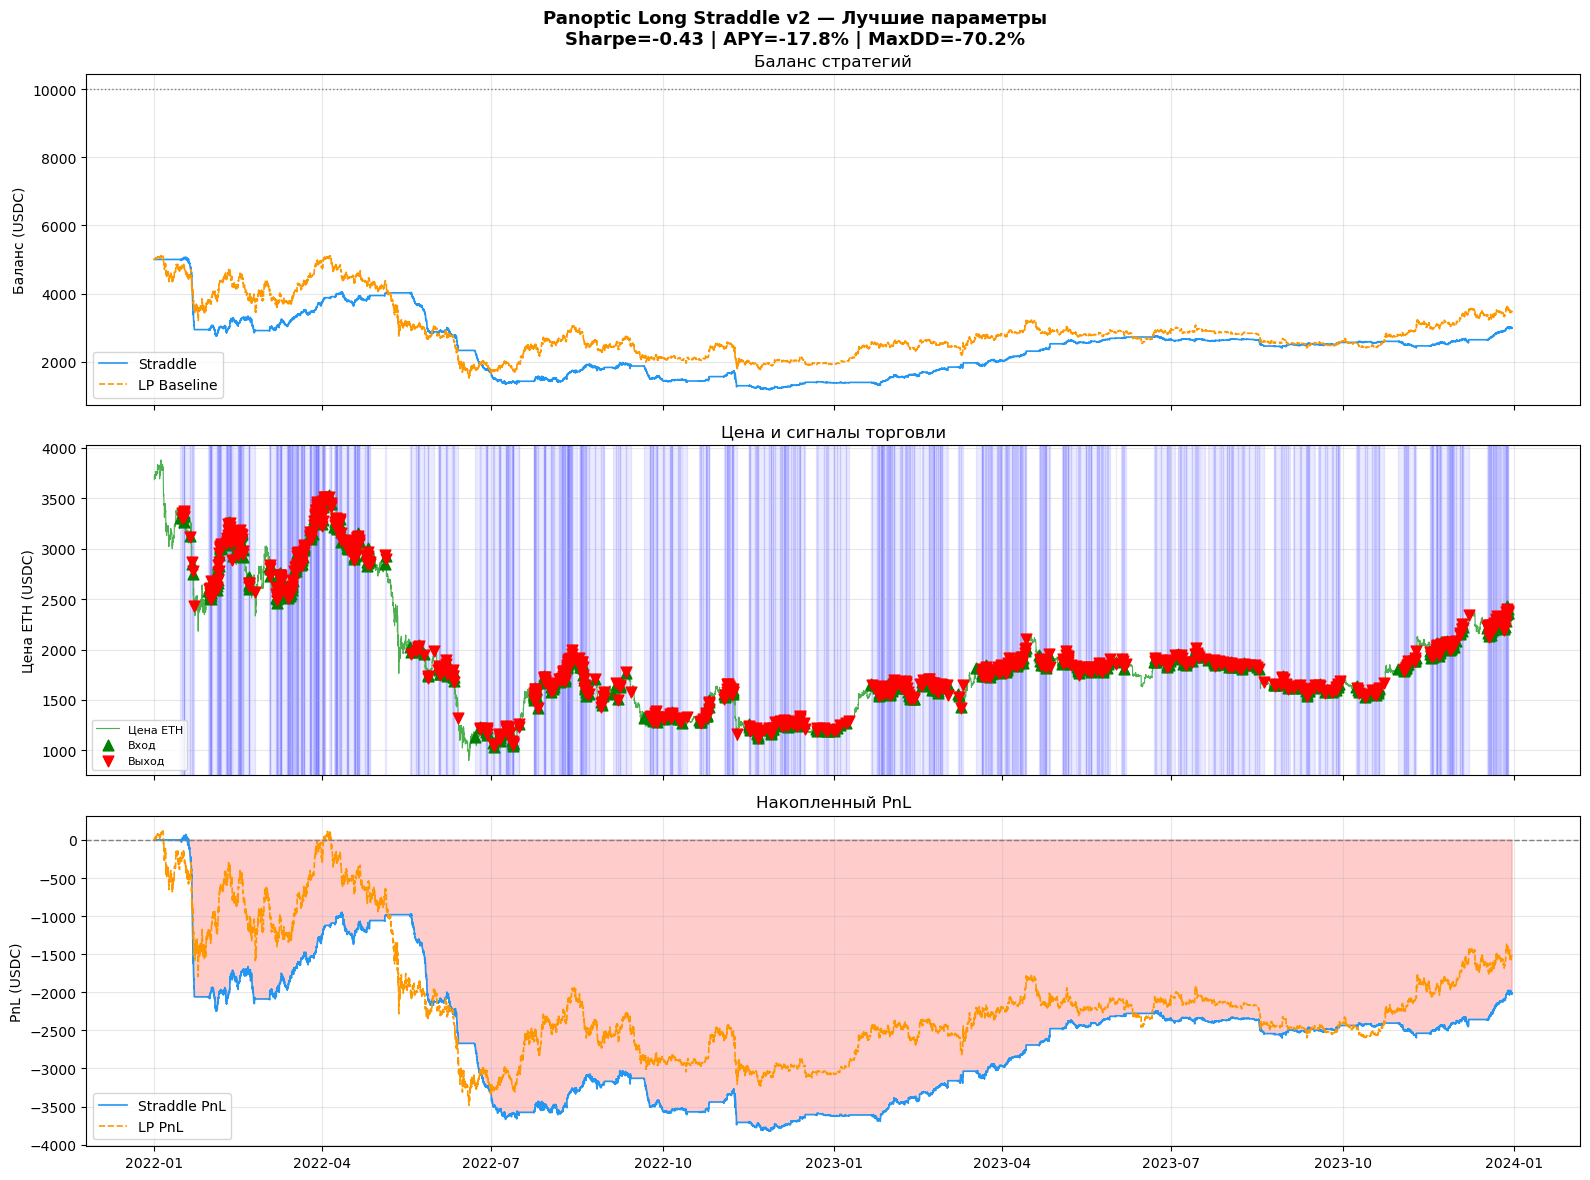

✅ Дашборд сохранён: final_dashboard.png


In [15]:
# ══════════════════════════════════════════
#  ИТОГОВЫЙ ДАШБОРД
# ══════════════════════════════════════════

df_best['price'] = df_pool['price'].values[:len(df_best)]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    f'Panoptic Long Straddle v2 — Лучшие параметры\n'
    f'Sharpe={best_metrics.sharpe:.2f} | '
    f'APY={best_metrics.apy:.1%} | '
    f'MaxDD={best_metrics.max_drawdown:.1%}',
    fontsize=13, fontweight='bold'
)

# ── 1. Балансы ────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(df_best['timestamp'], df_best['STRADDLE_balance'],
         label='Straddle', color='#2196F3', linewidth=1.2)
ax1.plot(df_best['timestamp'], df_best['LP_balance'],
         label='LP Baseline', color='#FF9800', linewidth=1.2, linestyle='--')
ax1.axhline(INITIAL_BALANCE, color='gray', linestyle=':', linewidth=1)
ax1.set_ylabel('Баланс (USDC)')
ax1.set_title('Баланс стратегий')
ax1.legend()
ax1.grid(alpha=0.3)

# ── 2. Цена + сигналы входа/выхода ───────────────────────
ax2 = axes[1]
ax2.plot(df_best['timestamp'], df_best['price'],
         color='#4CAF50', linewidth=0.8, label='Цена ETH')

if 'STRADDLE_is_open' in df_best.columns:
    is_open = df_best['STRADDLE_is_open'].astype(bool)
    entries = df_best[is_open & ~is_open.shift(1, fill_value=False)]
    exits   = df_best[~is_open & is_open.shift(1, fill_value=False)]

    ax2.scatter(entries['timestamp'], entries['price'],
                marker='^', color='green', s=60, zorder=5, label='Вход')
    ax2.scatter(exits['timestamp'], exits['price'],
                marker='v', color='red', s=60, zorder=5, label='Выход')

    # Закрашиваем периоды удержания
    for _, entry_row in entries.iterrows():
        matching = exits[exits['timestamp'] > entry_row['timestamp']]
        if not matching.empty:
            ax2.axvspan(entry_row['timestamp'], matching.iloc[0]['timestamp'],
                        alpha=0.08, color='blue')

ax2.set_ylabel('Цена ETH (USDC)')
ax2.set_title('Цена и сигналы торговли')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 3. Накопленный PnL ────────────────────────────────────
ax3 = axes[2]
straddle_pnl = df_best['STRADDLE_balance'] - INITIAL_BALANCE / 2
lp_pnl       = df_best['LP_balance']       - INITIAL_BALANCE / 2

ax3.plot(df_best['timestamp'], straddle_pnl,
         label='Straddle PnL', color='#2196F3', linewidth=1.2)
ax3.plot(df_best['timestamp'], lp_pnl,
         label='LP PnL', color='#FF9800', linewidth=1.2, linestyle='--')
ax3.axhline(0, color='gray', linestyle='--', linewidth=1)
ax3.fill_between(df_best['timestamp'], straddle_pnl, 0,
                 where=(straddle_pnl >= 0), alpha=0.2, color='green')
ax3.fill_between(df_best['timestamp'], straddle_pnl, 0,
                 where=(straddle_pnl < 0), alpha=0.2, color='red')
ax3.set_ylabel('PnL (USDC)')
ax3.set_title('Накопленный PnL')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Дашборд сохранён: final_dashboard.png')

## Ячейка 15 — Итоговая таблица файлов

In [16]:
# ══════════════════════════════════════════
#  ИТОГ
# ══════════════════════════════════════════

import os

files = {
    'pool_data.csv':            'Исторические данные пула',
    'backtest_result.csv':      'Результаты дефолтного прогона',
    'grid_search_results.csv':  'Все комбинации Grid Search',
    'best_result.csv':          'Результаты лучших параметров',
    'pool_data.png':            'График данных пула',
    'backtest_results.png':     'График дефолтного бэктеста',
    'grid_search_analysis.png': 'Анализ Grid Search',
    'final_dashboard.png':      'Итоговый дашборд',
}

print('📁 Сохранённые файлы:')
for filename, description in files.items():
    size   = os.path.getsize(filename) if os.path.exists(filename) else 0
    status = '✅' if size > 0 else '❌'
    print(f'   {status} {filename:<35} {description}')

print(f"\n{'='*55}")
print(f'  ФИНАЛЬНОЕ СРАВНЕНИЕ')
print(f"{'='*55}")
print(f'  Метрика          Straddle      LP Baseline')
print(f"  {'─'*45}")
print(f'  Total Return   {best_metrics.accumulated_return:>10.2%}   {lp_return_best:>10.2%}')
print(f'  APY            {best_metrics.apy:>10.2%}   {"N/A":>10}')
print(f'  Sharpe         {best_metrics.sharpe:>10.3f}   {"N/A":>10}')
print(f'  Max Drawdown   {best_metrics.max_drawdown:>10.2%}   {"N/A":>10}')
print(f'  Итог. IL       {"N/A":>10}   ${best_lp.impermanent_loss:>9.2f}')
print(f"{'='*55}")

📁 Сохранённые файлы:
   ✅ pool_data.csv                       Исторические данные пула
   ✅ backtest_result.csv                 Результаты дефолтного прогона
   ✅ grid_search_results.csv             Все комбинации Grid Search
   ✅ best_result.csv                     Результаты лучших параметров
   ✅ pool_data.png                       График данных пула
   ✅ backtest_results.png                График дефолтного бэктеста
   ✅ grid_search_analysis.png            Анализ Grid Search
   ✅ final_dashboard.png                 Итоговый дашборд

  ФИНАЛЬНОЕ СРАВНЕНИЕ
  Метрика          Straddle      LP Baseline
  ─────────────────────────────────────────────
  Total Return      -35.53%      -30.87%
  APY               -17.79%          N/A
  Sharpe             -0.429          N/A
  Max Drawdown      -70.22%          N/A
  Итог. IL              N/A   $   900.62
